In [2]:
!pip install wbdata
!pip install eurostat
import wbdata
import eurostat
import pandas as pd
import matplotlib.pyplot as plt
import json

In [83]:
#The Datasets
toc_df = eurostat.get_toc_df()
eurostat.subset_toc_df(toc_df, "energy balance")
eurostat.subset_toc_df(toc_df, "renewable")

,title,code,type,last update of data,last table structure change,data start,data end
180,Renewable freshwater resources,MED_EN41,dataset,2015-12-10T23:00:00+0100,2024-01-10T23:00:00+0100,2000,2012
1068,"Supply, transformation and consumption of rene...",NRG_CB_RW,dataset,2024-08-14T23:00:00+0200,2024-06-07T23:00:00+0200,1990,2023
1178,Renewable cooling - ambient energy by technology,NRG_IND_RCAEBT,dataset,2024-07-19T23:00:00+0200,2024-04-25T11:00:00+0200,2021,2022
1180,Renewable cooling - technical characteristics ...,NRG_IND_RCTCBT,dataset,2024-07-19T23:00:00+0200,2024-07-19T23:00:00+0200,2021,2022
1182,Share of energy from renewable sources,NRG_IND_REN,dataset,2024-09-19T23:00:00+0200,2024-09-19T23:00:00+0200,2004,2022
1185,Contribution of renewable fuels to gross final...,NRG_IND_RFCE,dataset,2024-07-19T23:00:00+0200,2024-07-19T23:00:00+0200,2021,2022
1187,Share of renewable fuels in gross final consum...,NRG_IND_RFCER,dataset,2024-07-19T23:00:00+0200,2024-07-19T23:00:00+0200,2021,2022
1189,Share of renewable fuels in total gross final ...,NRG_IND_RFTCE,dataset,2024-07-19T23:00:00+0200,2024-07-19T23:00:00+0200,2021,2022
1193,Use of renewables for electricity - details,NRG_IND_URED,dataset,2024-07-19T23:00:00+0200,2024-04-25T11:00:00+0200,2004,2022
1195,Use of renewables for heating and cooling - de...,NRG_IND_URHCD,dataset,2024-07-19T23:00:00+0200,2024-04-25T11:00:00+0200,2004,2022


In [84]:
#Preprocessing 
import wbdata
import eurostat
import pandas as pd
import matplotlib.pyplot as plt
import json


# IDs for World bank data
EU = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta",
    "Netherlands", "Poland", "Portugal", "Romania", "Slovak Republic", "Slovenia",
    "Spain", "Sweden"
]
EU_IDS = []
for country in EU:
    result = wbdata.get_countries(query=country)
    try:
        EU_IDS.append(result[0]["id"])
    except:
        print(f"No result for {country}")


# Dictionary with abbreviations as to the convention of Eurostat datasets from all member states
EU_MEMBERS = {
    "Belgium": "BE", "Bulgaria": "BG", "Czechia": "CZ", "Denmark": "DK",
    "Germany": "DE", "Estonia": "EE", "Ireland": "IE", "Greece": "EL",
    "Spain": "ES", "France": "FR", "Croatia": "HR", "Italy": "IT",
    "Cyprus": "CY", "Latvia": "LV", "Lithuania": "LT", "Luxembourg": "LU",
    "Hungary": "HU", "Malta": "MT", "Netherlands": "NL", "Austria": "AT",
    "Poland": "PL", "Portugal": "PT", "Romania": "RO", "Slovenia": "SI",
    "Slovakia": "SK", "Finland": "FI", "Sweden": "SE"
}

In [85]:
# Energy balance df

nrg_balance_df = eurostat.get_data_df(code="NRG_BAL_S")

nrg_balance_df.info()
print("Available measures: \n", nrg_balance_df["nrg_bal"].unique())
print("Available units: \n", nrg_balance_df["unit"].unique())
print("SIEC values: \n", nrg_balance_df["siec"].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134634 entries, 0 to 134633
Data columns (total 38 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   freq             134634 non-null  object 
 1   nrg_bal          134634 non-null  object 
 2   siec             134634 non-null  object 
 3   unit             134634 non-null  object 
 4   geo\TIME_PERIOD  134634 non-null  object 
 5   1990             77526 non-null   float64
 6   1991             77526 non-null   float64
 7   1992             77526 non-null   float64
 8   1993             77526 non-null   float64
 9   1994             77526 non-null   float64
 10  1995             77526 non-null   float64
 11  1996             77526 non-null   float64
 12  1997             77526 non-null   float64
 13  1998             77526 non-null   float64
 14  1999             77526 non-null   float64
 15  2000             79680 non-null   float64
 16  2001             79680 non-null   floa

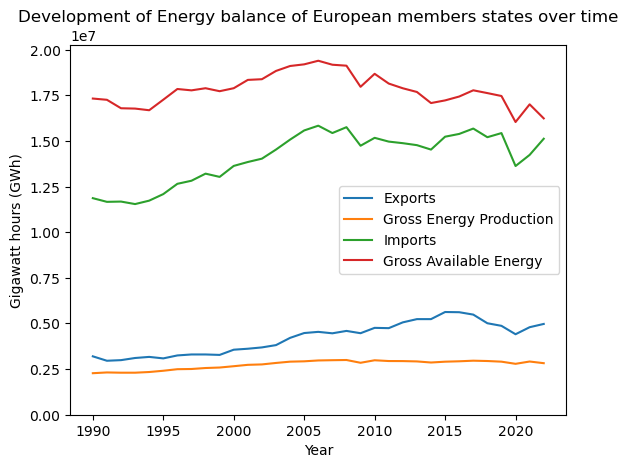

In [86]:
years = [str(x) for x in range(1990, 2023)]
nrg_units_filter = nrg_balance_df["unit"] == "GWH"
country_filter = nrg_balance_df["geo\\TIME_PERIOD"] == "EU27_2020"
nrg_classifier_filter = nrg_balance_df["siec"] == "TOTAL"
nrg_types_filter = nrg_balance_df["nrg_bal"].isin(["GEP", "EXP", "IMP", "AFC", "GAE"])


small_df = nrg_balance_df[country_filter & nrg_units_filter & nrg_classifier_filter & nrg_types_filter]

plt.ylabel("Gigawatt hours (GWh)")
plt.xlabel("Year")

plt.plot(range(1990, 2023), small_df[small_df["nrg_bal"] == "EXP"][years].iloc[0], label="Exports")
plt.plot(range(1990, 2023), small_df[small_df["nrg_bal"] == "GEP"][years].iloc[0], label="Gross Energy Production")
plt.plot(range(1990, 2023), small_df[small_df["nrg_bal"] == "IMP"][years].iloc[0], label="Imports")
plt.plot(range(1990, 2023), small_df[small_df["nrg_bal"] == "GAE"][years].iloc[0], label="Gross Available Energy")

plt.title("Development of Energy balance of European members states over time")
plt.ylim(bottom=0)
plt.legend()
plt.show()

C:\Users\macdo\AppData\Local\Temp\ipykernel_12004\3430662235.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nrg_vals = nrg_country[nrg_classifier_filter & nrg_types_filter & nrg_units_filter]


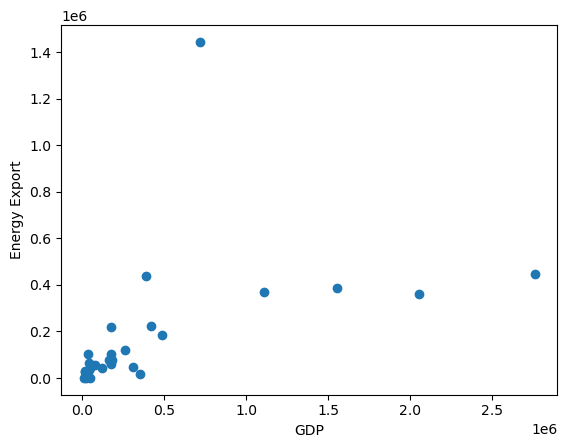

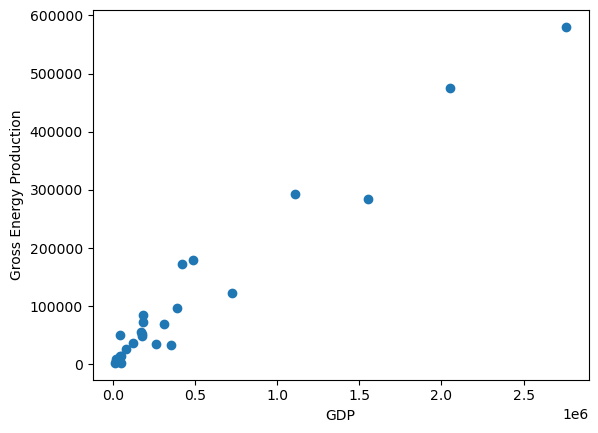

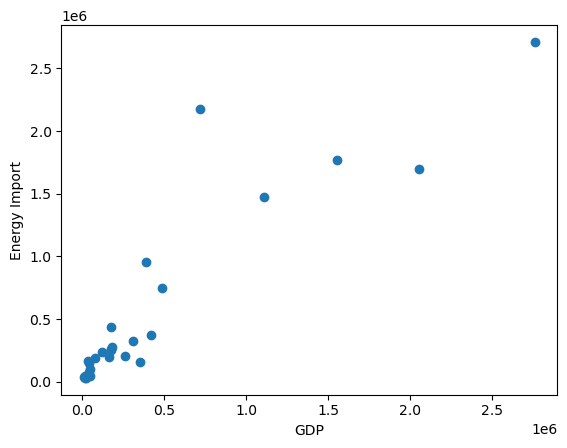

In [87]:
# Analysis regarding GDP

# Loading data and ensuring it is only for member states
gdp_df = eurostat.get_data_df("NAMA_10_GDP")
gdp_country = gdp_df[gdp_df["geo\\TIME_PERIOD"].isin(EU_MEMBERS.values())]

# B1G is code for GDP, there are many GDP measures
gdp_classifier_filter = gdp_country["na_item"] == "B1G"
sth = gdp_country[(gdp_country["unit"] == "CLV10_MEUR") & gdp_classifier_filter ].sort_values(by="geo\\TIME_PERIOD")
sth.dropna(axis=1, inplace=True)

sth.sort_values(by="geo\\TIME_PERIOD")

gdp_vals = sth["2022"]
# print(gdp_vals)

nrg_country = nrg_balance_df[ nrg_balance_df["geo\\TIME_PERIOD"].isin(EU_MEMBERS.values())]
nrg_vals = nrg_country[nrg_classifier_filter & nrg_types_filter & nrg_units_filter]
nrg_vals["geo\\TIME_PERIOD"]


def create_country_graphs(category: str, name):
    nrg_country_exp = nrg_vals[nrg_vals["nrg_bal"] == category][["2022", "geo\\TIME_PERIOD"]]
    nrg_country_exp.sort_values(by="geo\\TIME_PERIOD")
    plt.scatter(gdp_vals, nrg_country_exp["2022"])
    plt.xlabel("GDP")
    plt.ylabel(name)
    plt.show()

create_country_graphs("EXP", "Energy Export")
create_country_graphs("GEP", "Gross Energy Production")
create_country_graphs("IMP", "Energy Import")



In [ ]:
# Check if the filtered data is still empty
#if eu_data.empty:
 #   print("No data found for the specified EU member countries.")
#else:
 #   print("Filtered data for EU members:")
  #  display(eu_data.head())

    # Step 2: Sum the renewable energy share across all EU members for each year
   # yearly_totals = eu_data.iloc[:, 4:].sum(axis=0)  # Adjusted index to 4th column onward for years


# Filter for rows where `nrg_bal` is 'REN' to get only total renewable energy data
#renewables = eu_data[eu_data['nrg_bal'] == 'REN']

# Display the first few rows to verify
#print(renewables.head())



In [92]:
eu_member_codes = list(EU_MEMBERS.values())
renewables = eu_data[eu_data['nrg_bal'] == 'REN']
eu_data = renewable_energy_df[renewable_energy_df["geo\\TIME_PERIOD"].isin(eu_member_codes)]

#years = range(2004,2023)

print(renewables)


   freq nrg_bal unit geo\TIME_PERIOD    2004    2005    2006    2007    2008  \
1     A     REN   PC              AT  22.553  24.353  26.276  28.144  28.788   
3     A     REN   PC              BE   1.916   2.325   2.658   3.140   3.611   
4     A     REN   PC              BG   9.231   9.173   9.415   9.098  10.345   
5     A     REN   PC              CY   3.071   3.131   3.263   4.001   5.131   
6     A     REN   PC              CZ   6.773   7.113   7.362   7.895   8.674   
7     A     REN   PC              DE   6.207   7.167   8.466  10.039  10.072   
8     A     REN   PC              DK  14.839  15.955  16.332  17.747  18.543   
9     A     REN   PC              EE  18.420  17.478  16.011  17.139  18.811   
10    A     REN   PC              EL   7.161   7.277   7.458   8.249   8.183   
11    A     REN   PC              ES   8.345   8.444   9.156   9.667  10.744   
13    A     REN   PC              FI  29.232  28.814  30.043  29.561  31.071   
14    A     REN   PC              FR   9

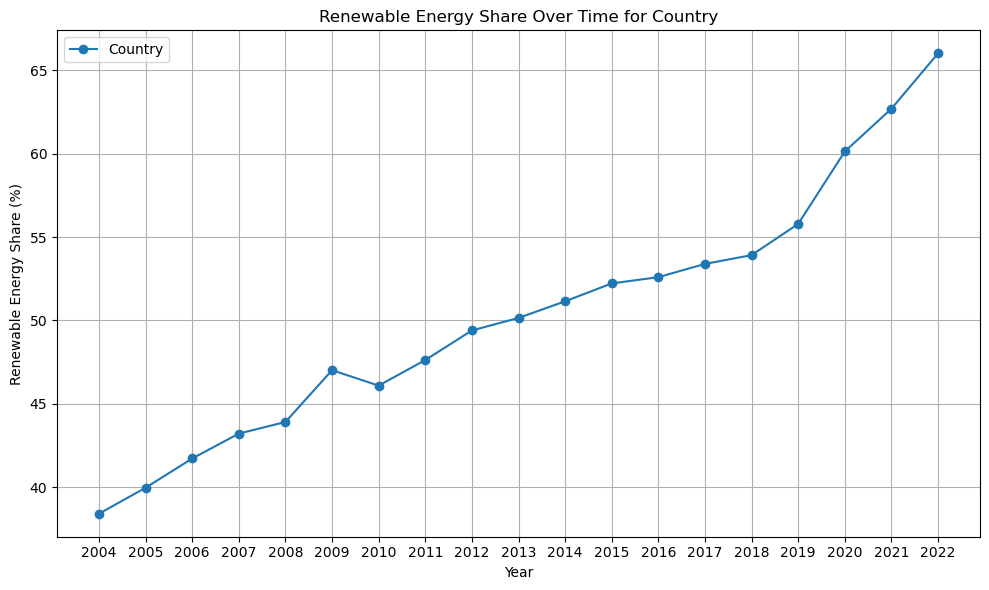

In [94]:

# Filter for desired country 
country_data = renewables[renewables["geo\\TIME_PERIOD"] == "SE"]

year_columns = [str(year) for year in range(2004, 2023)]


renewable_share = country_data.iloc[0][year_columns].astype(float).values 

    
plt.figure(figsize=(10, 6))
plt.plot(year_columns, renewable_share, marker='o', label='Country')
plt.xlabel("Year")
plt.ylabel("Renewable Energy Share (%)")
plt.title("Renewable Energy Share Over Time for Country")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

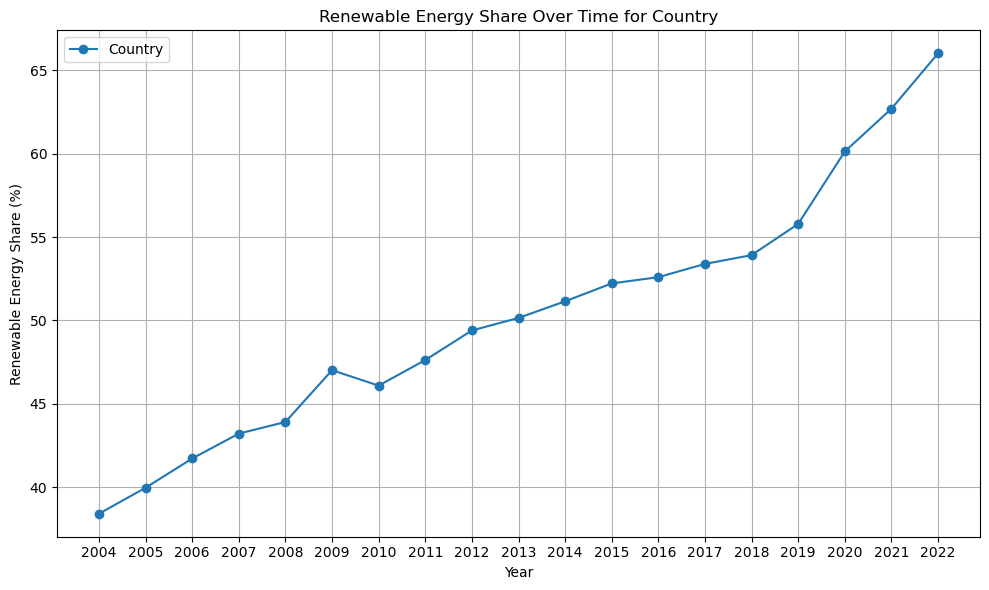

In [89]:

# Filter for desired country 
country_data = renewables[renewables["geo\\TIME_PERIOD"] == "SE"]

year_columns = [str(year) for year in range(2004, 2023)]


if not country_data.empty:
    renewable_share = country_data.iloc[0][year_columns].astype(float).values 

    
    plt.figure(figsize=(10, 6))
    plt.plot(year_columns, renewable_share, marker='o', label='Country')
    plt.xlabel("Year")
    plt.ylabel("Renewable Energy Share (%)")
    plt.title("Renewable Energy Share Over Time for Country")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for Country")


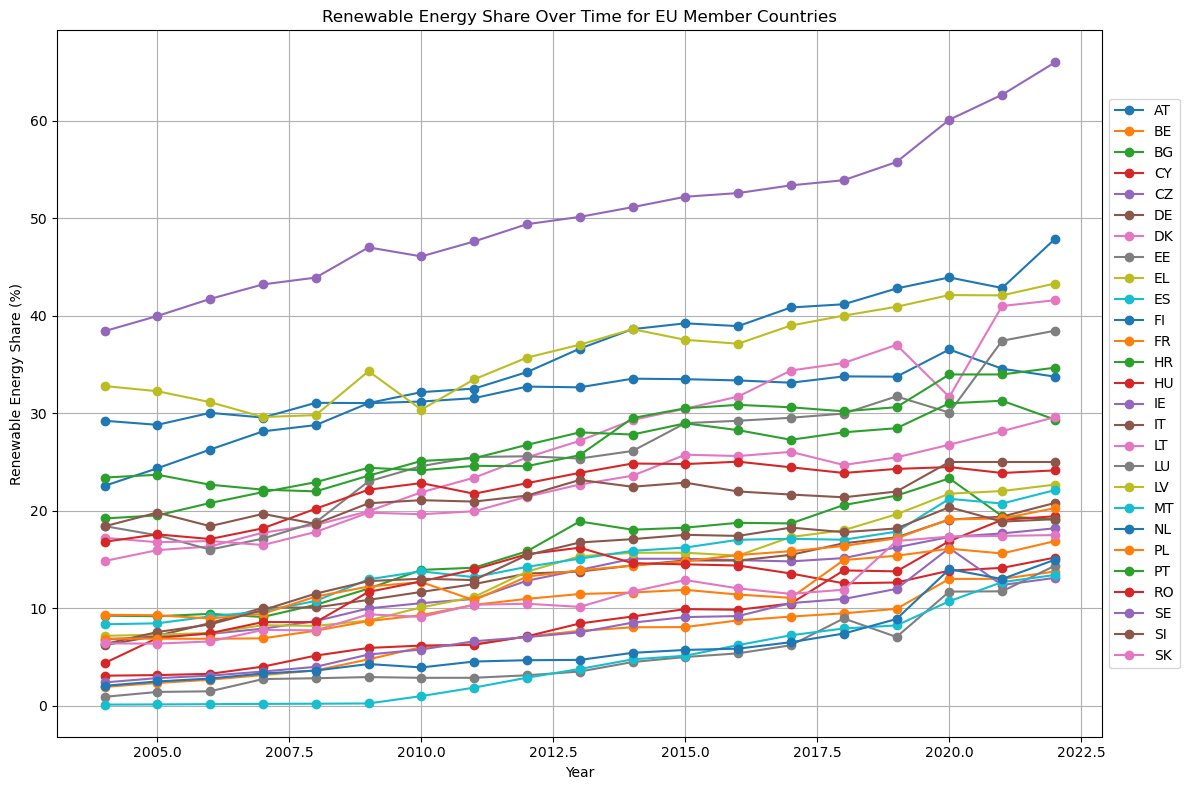

In [90]:
years = range(2004, 2023)

plt.figure(figsize=(12, 8))

for index, row in renewables.iterrows():
    country_code = row['geo\\TIME_PERIOD']
    renewable_share = row[4:].values
    
    plt.plot(years, renewable_share, marker='o', label=country_code)

plt.xlabel("Year")
plt.ylabel("Renewable Energy Share (%)")
plt.title("Renewable Energy Share Over Time for EU Member Countries")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
wbdata.get_indicators(source=57)

id                         name
-------------------------  ---------------------------------------------------------------------------------------------------------------------------------------------
AG.AGR.TRAC.NO             Agricultural machinery, tractors
AG.AID.CREL.MT             Cereal food aid deliveries (FAO, tonnes)
AG.CON.FERT.MT             Fertilizer consumption (metric tons)
AG.CON.FERT.PT.ZS          Fertilizer consumption (% of fertilizer production)
AG.CON.FERT.ZS             Fertilizer consumption (kilograms per hectare of arable land)
AG.CON.PEST.MT             Pesticide consumption (metric tons)
AG.IMP.CREL.MT             Cereal imports (metric tons)
AG.LND.AGRI.HA             Agricultural land (hectares)
AG.LND.AGRI.K2             Agricultural land (sq. km)
AG.LND.AGRI.ZS             Agricultural land (% of land area)
AG.LND.ARBL.HA             Arable land (hectares)
AG.LND.ARBL.HA.PC          Arable land (hectares per person)
AG.LND.ARBL.ZS             Arable lan